# Predicción X-OR

<p style='text-align: justify;'>Antes de definir con lujo de detalle cada uno de los componentes de la red neuronal y la matemática relacionada, te presentaremos una red pequeña con la finalidad de que te familiarices con el tema.  El objetivo de esta red será predecir si un número binario tiene una cantidad par o impar de bits con el valor de uno.</p> 

| A 	| B 	| C 	| Y 	|
|:--:	|:--:	|:--:	|:-:	|
|  0 	|  0 	|  0 	| 0 	|
|  0 	|  0 	|  1 	| 1 	|
| 0  	| 1  	| 0  	| 1 	|
| 0  	| 1  	| 1  	| 0 	|
| 1  	| 0  	| 0  	| 1 	|
| 1  	| 0  	| 1  	| 0 	|
|  1 	|  1 	|  0 	| 0 	|
| 1  	| 1  	| 1  	| 1 	|

<p style='text-align: justify;'>En la tabla anterior se muestra que en la primera entrada donde todos los bits son cero, la salida es cero pero en la última entrada donde todos los bits son uno, la salida es uno. Cuando tenemos una cantidad par de unos se asignará una salida de cero y en caso contrario se asigna una salida de uno. La red neuronal que verás a continuación funcionará de manera similar.</p> 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Arreglos de entrenamiento.
X = np.array(([0,0,0],
              [0,0,1],
              [0,1,0],
              [0,1,1],
              [1,0,0],
              [1,0,1],
              [1,1,0],
              [1,1,1]), dtype = float)

y = np.array(([0],
              [1],
              [1],
              [0],
              [1],
              [0],
              [0],
              [1]), dtype = float)

In [3]:
print(X)

[[0. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 1.]
 [1. 0. 0.]
 [1. 0. 1.]
 [1. 1. 0.]
 [1. 1. 1.]]


In [4]:
print(y)

[[0.]
 [1.]
 [1.]
 [0.]
 [1.]
 [0.]
 [0.]
 [1.]]


<center><img src="img/NN_XOR.png" width = "90%"></center>

In [5]:
lr = 0.5
w0 = np.random.randn(X.shape[1],4)
w1 = np.random.randn(4, 1)
output = np.zeros(y.shape)
Z0,z1,a0,a1,a2,errors = [],[],[],[],[],[]

In [6]:
# Pesos de la capa cero.
w0

array([[-0.07797246,  0.03497243,  0.1620554 ,  1.11532481],
       [-0.20711307, -0.23847116,  1.8170913 ,  0.23994953],
       [ 0.99787158, -0.65155848,  0.20377253, -0.48828944]])

In [7]:
# Pesos de la capa uno.
w1

array([[ 0.51983091],
       [-0.34127904],
       [ 1.28555402],
       [-0.65130542]])

In [8]:
# Conozcamos la salida.
output

array([[0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.],
       [0.]])

In [9]:
def sigmoid(t):
    return 1/(1+np.exp(-t))

def sigmoid_derivative(p):
    return sigmoid(p) * sigmoid(1 - p)

In [10]:
def feedforward(X_input):
    
    #np.dot regresa el producto punto de dos arreglos.
    global a0,z0,a1,z1,a2
    
    # La activación de la capa cero, es la entrada.
    a0 = X_input
    z0 = np.dot(a0,w0) # NOTA: En esta sección se sumarían los baias si existieran.
    
    # La activación de la capa uno, es la información de las neuronas anteriores (Entradas)  
    # a través de la función de activación "sigmoide".
    a1 = sigmoid(z0)
    z1 = np.dot(a1,w1)
    
    # La activación de la capa dos, es la información de las neuronas anteriores (Capa 1)  
    # a través de la función de activación "sigmoide".
    a2 = sigmoid(z1)
    
    # En esta red, aquí terminamos, porque no hay más capas.
    output = a2
    
    return output

In [11]:
def backprop():
    # Aplicando la regla de la cadena para la función de perdida respecto a los pesos 2 y 1.
    # .T devuelve la matriz traspuesta
    global w0,w1,w2,b0,b1,b2
    
    # Calcular el error MSE --> Mean Square Error.
    mse = np.sum( (1 / 2) * (y - output) * (y - output))
    errors.append(mse)

    delta1 = -(y - output) * sigmoid_derivative(z1)
    d_w1 = np.dot(a1.T,delta1)
    d_b1 = delta1
    
    delta0 = np.dot(delta1,w1.T) * sigmoid_derivative(z0)
    d_w0 = np.dot(a0.T,delta0)
    d_b0 = delta0

    # lr --> Learning Rate, es un parametro propuesto por el investigador
    # que indica que tanta importancia le asignamos a los errores del pasado.
    w1 = w1 - lr * d_w1
    w0 = w0 - lr * d_w0

In [12]:
# Sesión de entrenamiento
repeticiones = 1000

for i in range(repeticiones):
    # Primero se realiza el feedforward y despues el back propagation
    output = feedforward(X)
    backprop()
    # Las siguientes líneas muestran el error cada 10 sesiones.
    if i % 10 == 0:
        print("Epoch: {}, mse: {}".format(i,errors[-1]))

Epoch: 0, mse: 1.121337151182672
Epoch: 10, mse: 1.0092230999222218
Epoch: 20, mse: 1.0067778133732364
Epoch: 30, mse: 1.0049696051531796
Epoch: 40, mse: 1.003570900651562
Epoch: 50, mse: 1.002438532766325
Epoch: 60, mse: 1.0014777683988627
Epoch: 70, mse: 1.0006219558651028
Epoch: 80, mse: 0.9998206756487418
Epoch: 90, mse: 0.9990322719971163
Epoch: 100, mse: 0.9982186400979228
Epoch: 110, mse: 0.9973410565979693
Epoch: 120, mse: 0.9963562609323007
Epoch: 130, mse: 0.9952121688400322
Epoch: 140, mse: 0.9938426467533329
Epoch: 150, mse: 0.9921607777328494
Epoch: 160, mse: 0.9900501057224721
Epoch: 170, mse: 0.9873536293088185
Epoch: 180, mse: 0.9838611384905569
Epoch: 190, mse: 0.9792972757996955
Epoch: 200, mse: 0.9733156015567532
Epoch: 210, mse: 0.9655065862651397
Epoch: 220, mse: 0.9554256462751137
Epoch: 230, mse: 0.9426368546870726
Epoch: 240, mse: 0.926754870038452
Epoch: 250, mse: 0.9074722662508017
Epoch: 260, mse: 0.8845886628463124
Epoch: 270, mse: 0.8580711712586997
Epoch: 

In [13]:
w0

array([[ 4.21823422,  6.29600855,  5.289487  , -1.95756212],
       [-7.13967749, -2.83901726,  4.79233928, -0.04277217],
       [ 3.98302008, -3.16264436, -8.34973799, -0.48110653]])

In [14]:
w1

array([[ 6.04997348],
       [-9.19831175],
       [ 6.88168292],
       [-7.30854225]])

# Usemos la red para predecir una entrada

Entrada propuesta $x = [1,0,1]$
<br>Salida esperada $y=0$ (Debido a que tiene un número Par de unos).

In [15]:
# La salida es igual a la predicción de la red ante una entrada.
output = feedforward([1,0,1])
output

array([0.04545658])

# Grafiquemos los errores. 

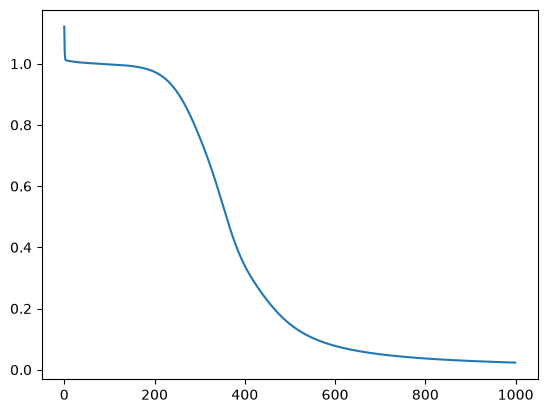

In [16]:
plt.plot(errors);

# ¿Cómo podemos mejorar el desempeño?
No existe una alternativa única pero se pueden intentar las siguientes alternativas:
<br>1) Incrementar la sesiones de entrenamiento.
<br>2) Experimentar modificando el valor de la taza de aprendizaje ($lr$).
<br>3) Proponer otra configuración de red neuronal.
<br>4) Incluir Baias. 

# Ejercicio

Vuelve a reiniciar la libreta pero antes de ejecutar las celdas donde se define el número de sesiones de entrenamiento, aumenta la variable de $200$ a $500$. Compara con el valor obtenido anterior de la predicción y del último error.